=== 1. RÉGRESSION LINÉAIRE SIMPLE ===
Coefficient (a) : -17121.21
Biais (b) : 210666.67

=== 2. RÉGRESSION LINÉAIRE MULTIPLE ===
Coefficients (Âge, Km) : [-27283.10502283    465.75342466]
Biais : 219981.74

=== 3. RÉGRESSION POLYNOMIALE ===
Coefficients polynomiaux : [     0.         -25246.21212121    738.63636364]



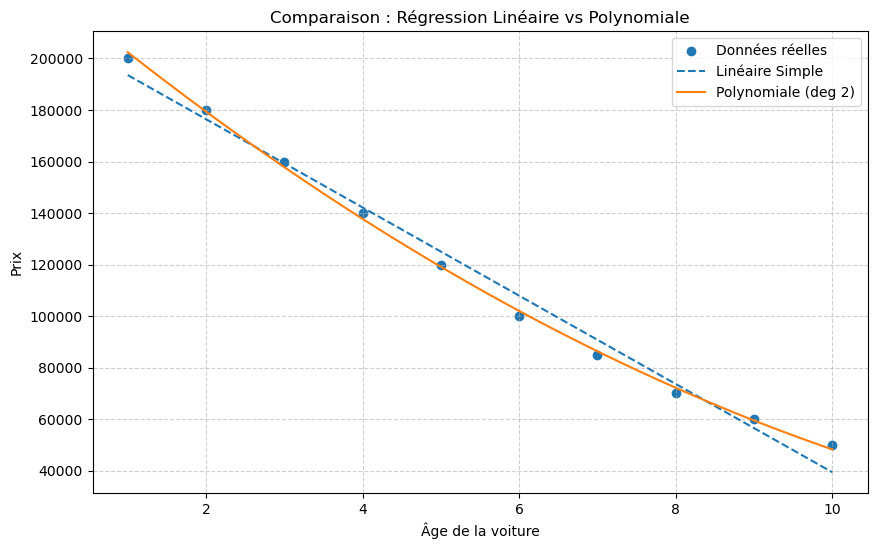

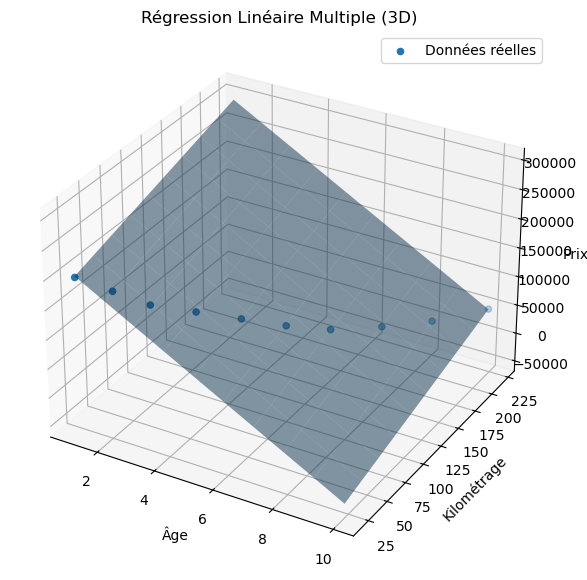

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Import des outils de régression de sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# =========================================================
# 1. PRÉPARATION DES DONNÉES (CAS DES VOITURES)
# =========================================================

# X_simple : Variable explicative unique
# Ici : âge de la voiture (en années)
X_simple = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)

# X_multiple : Deux variables explicatives
# Colonne 1 : âge
# Colonne 2 : kilométrage (en milliers de km)
X_multiple = np.array([[1, 20],[2, 30],[3, 40],[4, 60],[5, 80],[6, 100],[7, 120],[8, 150],[9, 180],[10, 220]])

# y : Variable cible (prix de la voiture en DH)
# Remarque : le prix diminue de manière non linéaire
y = np.array([200000, 180000, 160000, 140000, 120000, 100000, 85000, 70000, 60000, 50000])

# =========================================================
# 2. RÉGRESSION LINÉAIRE SIMPLE
# Modèle : y = a*x + b
# =========================================================

print("=== 1. RÉGRESSION LINÉAIRE SIMPLE ===")

# Création du modèle
model_simple = LinearRegression()
# Entraînement (apprentissage des paramètres a et b)
model_simple.fit(X_simple, y)
# Affichage des résultats
print(f"Coefficient (a) : {model_simple.coef_[0]:.2f}")
print(f"Biais (b) : {model_simple.intercept_:.2f}\n")
# Prédictions
y_pred_simple = model_simple.predict(X_simple)

# =========================================================
# 3. RÉGRESSION LINÉAIRE MULTIPLE
# Modèle : y = a1*x1 + a2*x2 + b
# =========================================================

print("=== 2. RÉGRESSION LINÉAIRE MULTIPLE ===")

# Création du modèle
model_mult = LinearRegression()
# Entraînement avec 2 variables (âge + km)
model_mult.fit(X_multiple, y)
# Résultats
print(f"Coefficients (Âge, Km) : {model_mult.coef_}")
print(f"Biais : {model_mult.intercept_:.2f}\n")

# =========================================================
# 4. RÉGRESSION POLYNOMIALE (DEGRÉ 2)
# Modèle : y = a*x + b*x² + c
# =========================================================

print("=== 3. RÉGRESSION POLYNOMIALE ===")

# Transformation des données (ajout de x²)
poly_features = PolynomialFeatures(degree=2)
# Création de nouvelles features : [1, x, x²]
X_poly = poly_features.fit_transform(X_simple)
# Modèle linéaire appliqué aux données transformées
model_poly = LinearRegression()
# Entraînement
model_poly.fit(X_poly, y)
# Affichage des coefficients
print(f"Coefficients polynomiaux : {model_poly.coef_}\n")
# Prédictions
y_pred_poly = model_poly.predict(X_poly)

# =========================================================
# 5. VISUALISATION COMPARATIVE (SIMPLE + POLY)
# =========================================================

plt.figure(figsize=(10,6))

# ------------------------------
# Données réelles
# ------------------------------
plt.scatter(X_simple, y, label="Données réelles")

# ------------------------------
# Régression linéaire
# ------------------------------
plt.plot(X_simple, y_pred_simple,linestyle='--',label="Linéaire Simple")

# ------------------------------
# Régression polynomiale
# ------------------------------
# Création d’un axe plus précis pour une courbe lisse
X_range = np.linspace(1, 10, 100).reshape(-1,1)
X_range_poly = poly_features.transform(X_range)

plt.plot(X_range, model_poly.predict(X_range_poly), label="Polynomiale (deg 2)")

# ------------------------------
# Mise en forme
# ------------------------------
plt.title("Comparaison : Régression Linéaire vs Polynomiale")
plt.xlabel("Âge de la voiture")
plt.ylabel("Prix")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# =========================================================
# 6. VISUALISATION 3D (RÉGRESSION MULTIPLE)
# =========================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Variables
age = X_multiple[:,0]
km = X_multiple[:,1]

# Points réels
ax.scatter(age, km, y, label="Données réelles")

# Création d'une grille
age_grid, km_grid = np.meshgrid(np.linspace(age.min(), age.max(), 10),np.linspace(km.min(), km.max(), 10))

# Plan du modèle
z_pred = model_mult.predict(np.c_[age_grid.ravel(), km_grid.ravel()]).reshape(age_grid.shape)

# Surface
ax.plot_surface(age_grid, km_grid, z_pred, alpha=0.5)

# Labels
ax.set_title("Régression Linéaire Multiple (3D)")
ax.set_xlabel("Âge")
ax.set_ylabel("Kilométrage")
ax.set_zlabel("Prix")

plt.legend()
plt.show()